# Problem Title - Exploration
Issue: #<issue-number>

## 1. Setup and Imports
Import pandas, matplotlib, and seaborn, then configure clean plotting defaults once.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# better visuals
sns.set(style="whitegrid")

## 2. Load and Inspect Data
Load dataset.csv and quickly check shape, column types, missing values, and sample rows.

In [4]:
url = "https://raw.githubusercontent.com/iiitl/Linear-Regression/main/dataset.csv"
df = pd.read_csv(url)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Concrete compressive strength,0


In [9]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [11]:
df.shape

(1030, 9)

## 3. EDA (Distributions and Correlations)
Analyze feature distributions, outliers, and correlations that affect modeling decisions.

In [13]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [14]:
corr_matrix = numeric_df.corr()
corr_matrix.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079


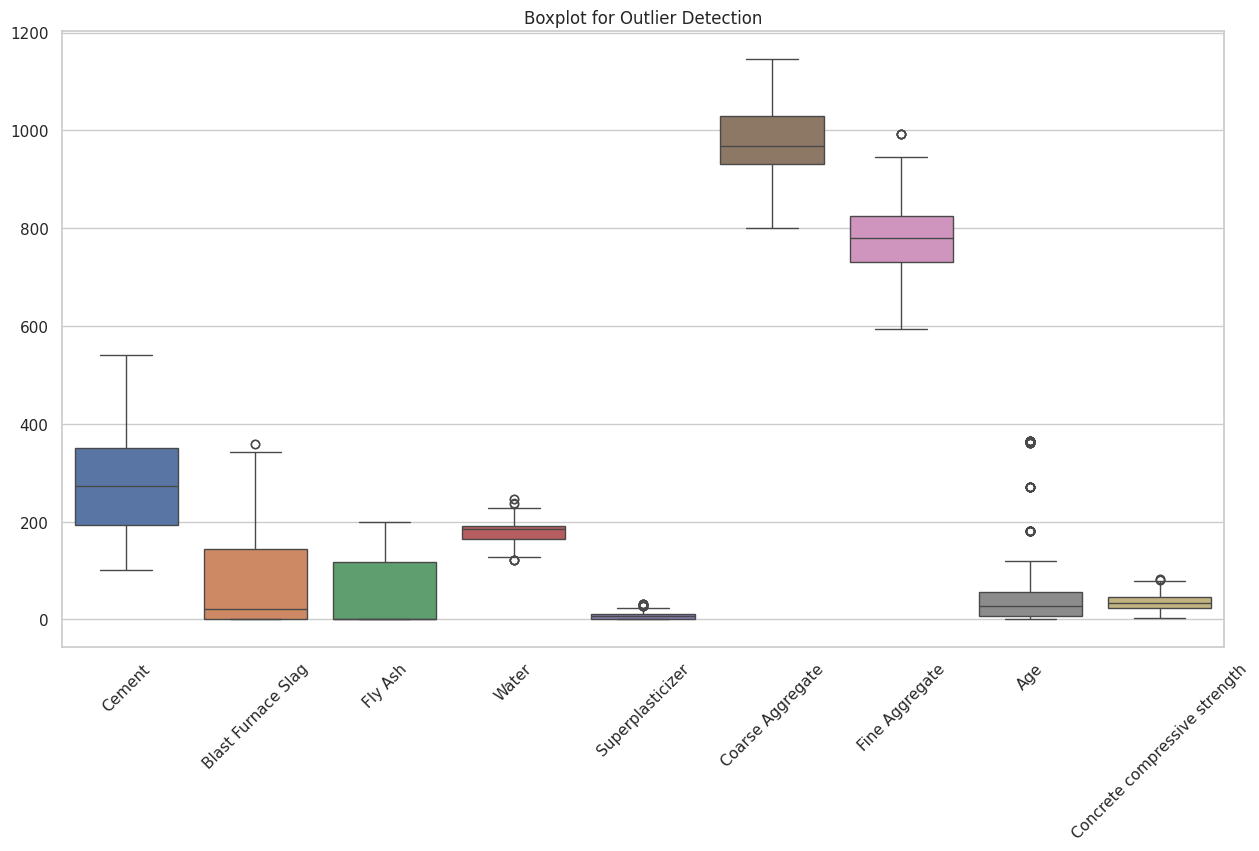

In [22]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=numeric_df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [23]:
outlier_summary = {}

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = numeric_df[(numeric_df[col] < lower) | (numeric_df[col] > upper)]
    outlier_summary[col] = len(outliers)

print("\nOutlier Count per Feature:\n")
print(pd.Series(outlier_summary).sort_values(ascending=False))



Outlier Count per Feature:

Age                              59
Superplasticizer                 10
Water                             9
Fine Aggregate                    5
Concrete compressive strength     4
Blast Furnace Slag                2
Cement                            0
Fly Ash                           0
Coarse Aggregate                  0
dtype: int64


In [26]:
skewness = numeric_df.skew().sort_values(ascending=False)

print("\nFeature Skewness:\n")
print(skewness)



Feature Skewness:

Age                              3.269177
Superplasticizer                 0.907203
Blast Furnace Slag               0.800717
Fly Ash                          0.537354
Cement                           0.509481
Concrete compressive strength    0.416977
Water                            0.074628
Coarse Aggregate                -0.040220
Fine Aggregate                  -0.253010
dtype: float64


In [27]:
target = numeric_df.columns[-1]  # assumes last column is target

target_corr = corr[target].drop(target)

print("\nCorrelation with Target:\n")
print(target_corr.sort_values(ascending=False))

print("\nTop Influential Features:\n")
print(target_corr.abs().sort_values(ascending=False).head(5))


Correlation with Target:

Cement                0.497832
Superplasticizer      0.366079
Age                   0.328873
Blast Furnace Slag    0.134829
Fly Ash              -0.105755
Coarse Aggregate     -0.164935
Fine Aggregate       -0.167241
Water                -0.289633
Name: Concrete compressive strength, dtype: float64

Top Influential Features:

Cement              0.497832
Superplasticizer    0.366079
Age                 0.328873
Water               0.289633
Fine Aggregate      0.167241
Name: Concrete compressive strength, dtype: float64


## 4. Visualization (Matplotlib/Seaborn)
Create at least three relevant plots and explain what each one reveals.

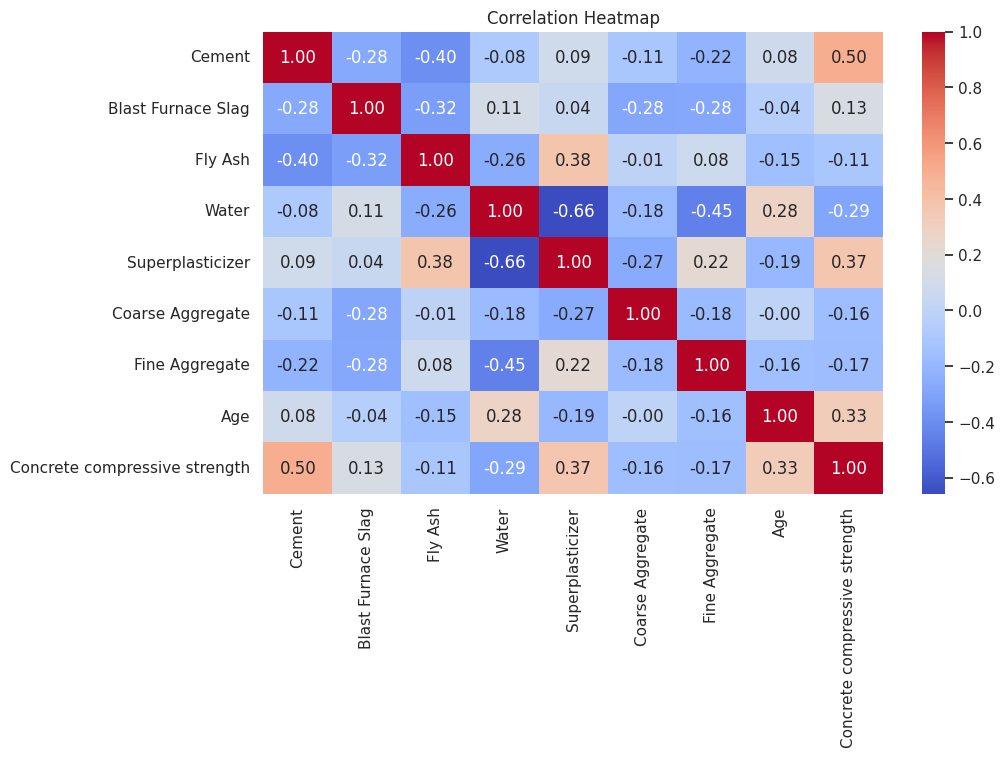

In [28]:
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

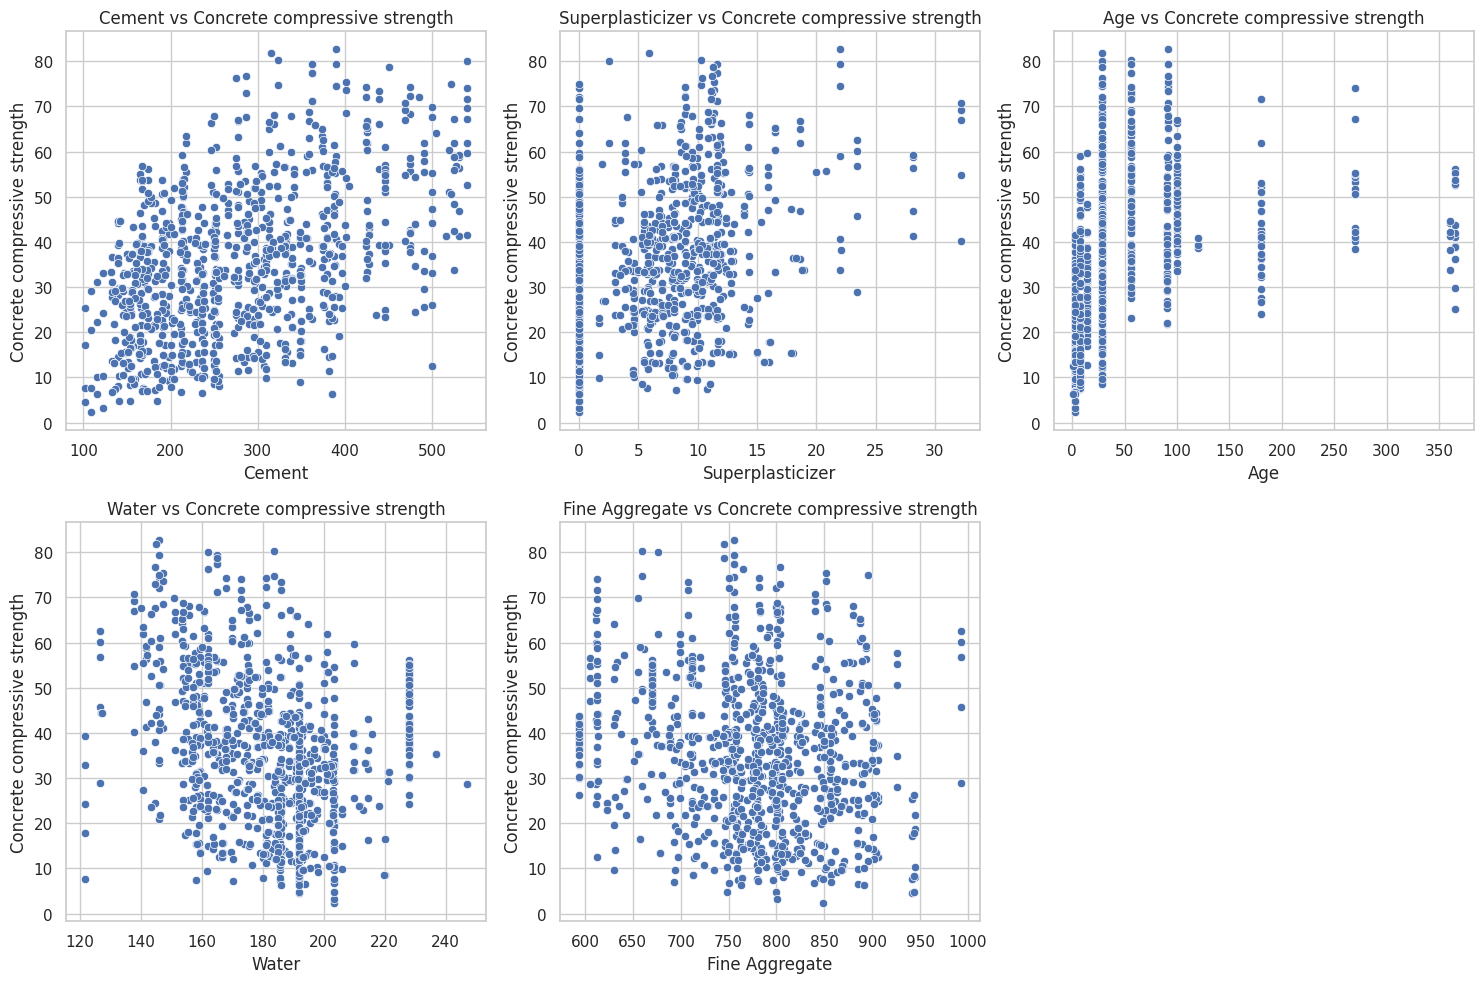

In [29]:
# choose target (update if needed)
target = numeric_df.columns[-1]

# get top 5 features
top_features = numeric_df.corr()[target].drop(target).abs().sort_values(ascending=False).head(5).index

plt.figure(figsize=(15, 10))

for i, feature in enumerate(top_features):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=df[feature], y=df[target])
    plt.title(f"{feature} vs {target}")

plt.tight_layout()
plt.show()

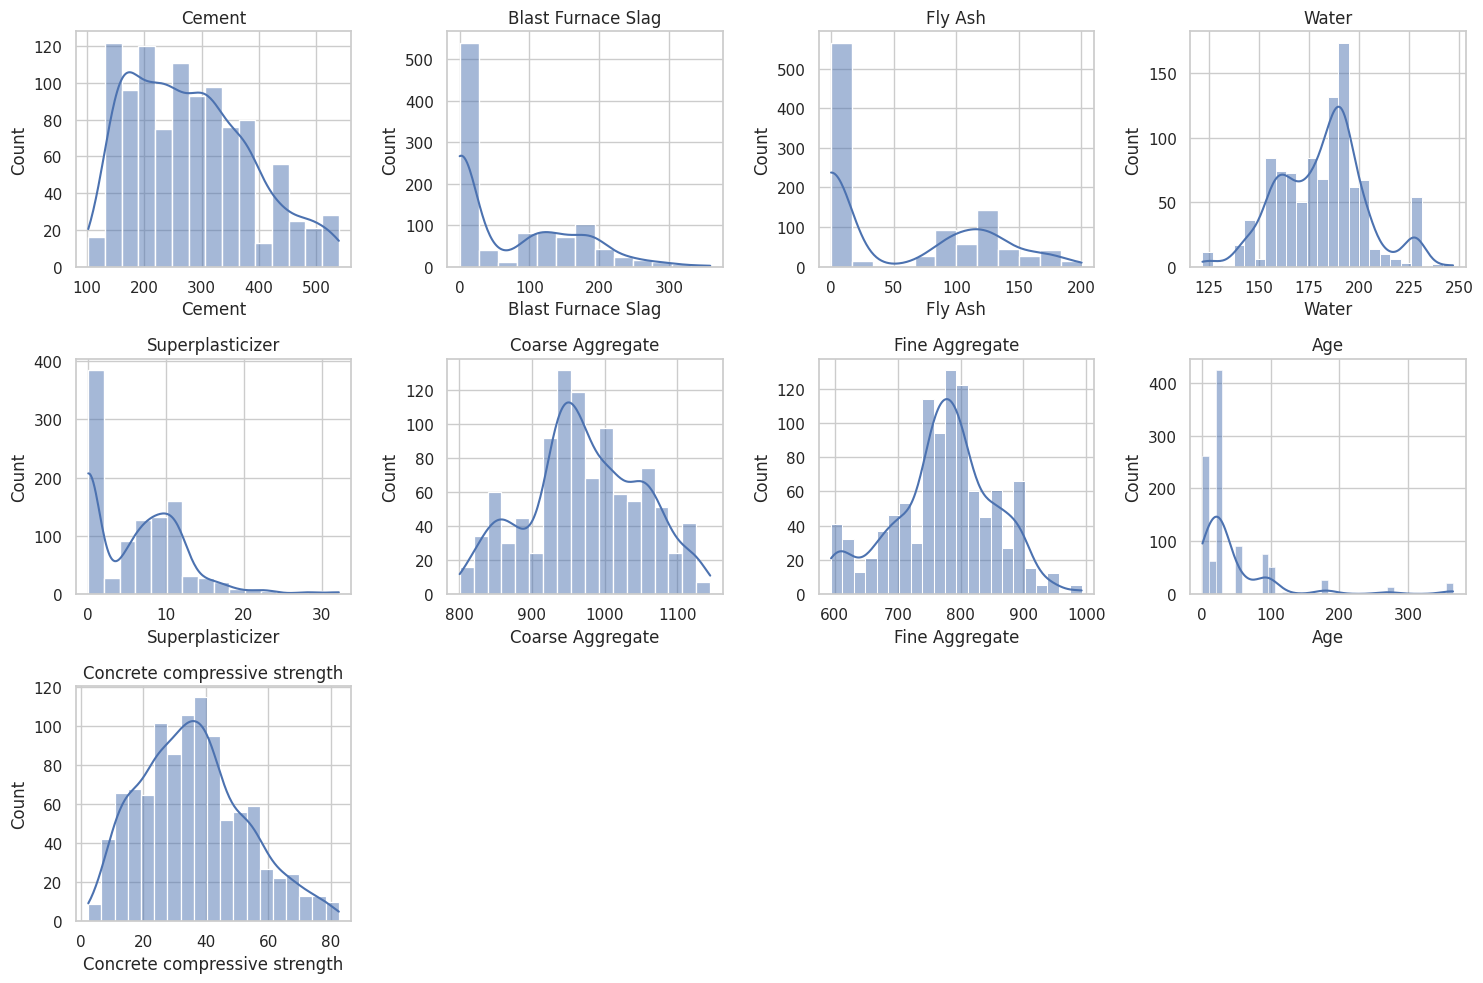

In [30]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(numeric_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## 5. Key Observations
Write three to five concise findings linked directly to your EDA and plots.

### Key Observations

1. The correlation heatmap shows that a few features have strong positive or negative relationships with the target, making them important predictors for the model.

2. Scatter plots of the top features reveal mostly linear relationships with the target, indicating that linear regression is an appropriate modeling choice.

3. Some features exhibit skewed distributions, suggesting that scaling or transformation (e.g., log) may improve model performance.

4. Boxplots highlight the presence of outliers in several features, which could negatively impact the model if not handled properly.

5. A few features show very weak correlation with the target, indicating they may contribute little to prediction and could be excluded.


## 6. Summary
Answer only these exploration-focused questions:
1. What are the top 3 dataset insights from your EDA?
2. Which plot gave the strongest insight, and why?
3. What data issues or patterns (imbalance, skew, outliers, multicollinearity) did your visualizations reveal?

### Answers

**1. Top 3 dataset insights**
- A few features show strong correlation with the target, making them key predictors.
- Most top features exhibit a linear relationship with the target.
- Some features are skewed and contain outliers, which may affect model performance.

**2. Most insightful plot**
- The correlation heatmap gave the strongest insight as it clearly highlights relationships between all features and the target at once.

**3. Data issues / patterns observed**
- Skewness in multiple features  
- Presence of outliers  
- Weakly correlated features (low importance)  
- Mild multicollinearity between some features